In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

PROJECT_ROOT = Path("/nfs/disk1/users/bharris/eos/analysis/sns-xscn-analysis")
sys.path.insert(0, str(PROJECT_ROOT))
import config as cfg

In [3]:
pmtchannel = [224, 112, 225, 226, 113, 227, 228, 114, 229, 230, 231, 115, 232, 233, 116, 234, 117, 235, 240, 118, 241, 242, 243, 244, 119, 245, 246, 120, 121, 247, 248, 122, 249, 250, 123, 251, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 184, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 185, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 186, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 187, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 188, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 189, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 190, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 204, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 205, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 206, 176, 177, 178, 179, 180, 181, 182, 183, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219]
pmtid = np.arange(0,241,1)


id2channel = dict(zip(pmtid, pmtchannel))

board_configs = {
    'barrel': [0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11],
    'top': [12, 13],
    'dichroic': [7],
    'bottom': [14, 15],
    'behind': [16]  # only 13 channels 
}

pmt_channels = {}
for region, boards in board_configs.items():
    channels = []
    for board in boards:
        n_channels = 13 if (region == 'behind') else 16
        channels.extend([16 * board + i for i in range(n_channels)])
    pmt_channels[region] = channels

top_channels = set(pmt_channels['top'])
bottom_channels = set(pmt_channels['bottom'] + pmt_channels['behind'] + pmt_channels['dichroic'])

max_id = max(pmtid)  # or 240 if fixed
is_top = np.zeros(max_id + 1, dtype=bool)
is_bottomlike = np.zeros(max_id + 1, dtype=bool)

for pid, ch in id2channel.items():
    if ch in top_channels:
        is_top[pid] = True
    elif ch in bottom_channels:
        is_bottomlike[pid] = True

In [28]:
# Data paths (detector: 'water' or '1wbls')
detector = 'water'
paths = {
    "oxygen": cfg.PREPROCESSED_DIR / f"{detector}_nueO16.npz",
    "cosmics": cfg.PREPROCESSED_DIR / f"{detector}_cosmics.npz",
    "eES": cfg.PREPROCESSED_DIR / f"{detector}_eES.npz",
}

norm_factors = {
    "oxygen": 473.0,
    "cosmics": 27000.0,
    "eES": 219.0,
}

emin, emax = cfg.ENERGY_MIN, cfg.ENERGY_MAX

# Train/test split used for the cross-validation-style ROC evaluation.
CV_TRAIN_FRACTION = 0.5
CV_SEED = 12345

# Define explicit bins once per variable, then reuse them below.
nbins = 7
# 21 11, 7
VAR_BINS = {
    "nhit": np.linspace(0, 250, nbins),
    "charge_std": np.linspace(0, 60, nbins),
    "zdir": np.linspace(-1,1, nbins),
    "xdir": np.linspace(-1, 1, nbins),
    "top bottom hit ratio": np.linspace(0, 3, nbins),
    "endcap energy/nhit": np.linspace(0, 2, nbins),
    "energy/nhit": np.linspace(0, 2, nbins),
}

# Each entry: (var1_name, var2_name, var1_bins, var2_bins)
VAR_COMBINATIONS = [
    ("charge_std", "nhit", VAR_BINS["charge_std"], VAR_BINS["nhit"]),
    ("charge_std", "zdir", VAR_BINS["charge_std"], VAR_BINS["zdir"]),
    ("charge_std", "top bottom hit ratio", VAR_BINS["charge_std"], VAR_BINS["top bottom hit ratio"]),
    ("charge_std", "energy/nhit", VAR_BINS["charge_std"], VAR_BINS["energy/nhit"]),
    ("charge_std", "endcap energy/nhit", VAR_BINS["charge_std"], VAR_BINS["endcap energy/nhit"]),
    ("nhit", "zdir", VAR_BINS["nhit"], VAR_BINS["zdir"]),
    ("nhit", "top bottom hit ratio", VAR_BINS["nhit"], VAR_BINS["top bottom hit ratio"]),
    ("nhit", "energy/nhit", VAR_BINS["nhit"], VAR_BINS["energy/nhit"]),
    ("nhit", "endcap energy/nhit", VAR_BINS["nhit"], VAR_BINS["endcap energy/nhit"]),
    ("zdir", "top bottom hit ratio", VAR_BINS["zdir"], VAR_BINS["top bottom hit ratio"]),
    ("zdir", "energy/nhit", VAR_BINS["zdir"], VAR_BINS["energy/nhit"]),
    ("zdir", "endcap energy/nhit", VAR_BINS["zdir"], VAR_BINS["endcap energy/nhit"]),
]

print(f"Detector: {detector}")
print(f"Energy range: {emin}–{emax} MeV")
print(f"Variable combinations: {len(VAR_COMBINATIONS)}")

Detector: water
Energy range: 20.0–75.0 MeV
Variable combinations: 12


In [29]:
def extract_var(data, name, emin, emax):
    """Extract variable from npz data with energy cut."""
    energy = np.asarray(data["energy"])
    mask = (energy >= emin) & (energy <= emax)
    if name == "energy":
        return energy[mask]
    if name == "nhit":
        return np.asarray(data["nhit"])[mask]
    if name == "charge_std":
        return np.asarray(data["charge_std"])[mask]
    if name == "zdir":
        return np.asarray(data["zdir"])[mask]
    if name == "xdir":
        return np.asarray(data["xdir"])[mask]
    if name == "top bottom hit ratio":
        ids = np.asarray(data["pmtid"])  # list of arrays of PMT ids
        var1 = []
        for event in ids:
            top_hits = is_top[event].sum()
            bottom_hits = is_bottomlike[event].sum()
            ratio = top_hits / (bottom_hits + 1e-6)
            var1.append(ratio)
        return np.asarray(var1)[mask]
    if name == "endcap energy/nhit":
        idsd = np.asarray(data["pmtid"])
        endcap_hits = []
        for event in idsd:
            top_hits = is_top[event].sum()
            bottom_hits = is_bottomlike[event].sum()
            endcap_hits.append(top_hits + bottom_hits + 1e-6)
        endcap_hits = np.asarray(endcap_hits)
        return np.asarray(data["energy"] / endcap_hits)[mask]
    if name == "energy/nhit":
        return np.asarray(data["energy"] / data["nhit"])[mask]
    raise ValueError(f"Unknown variable: {name}")


def split_train_test_arrays(arrays, train_fraction=0.5, seed=12345):
    """Split aligned 1D arrays into train/test halves with a reproducible shuffle."""
    n = len(arrays[0])
    if any(len(arr) != n for arr in arrays):
        raise ValueError("All arrays must have the same length before splitting")
    rng = np.random.default_rng(seed)
    order = rng.permutation(n)
    n_train = int(train_fraction * n)
    n_train = max(1, min(n - 1, n_train))
    train_idx = order[:n_train]
    test_idx = order[n_train:]
    train_arrays = [arr[train_idx] for arr in arrays]
    test_arrays = [arr[test_idx] for arr in arrays]
    return train_arrays, test_arrays


def compute_roc_for_combination(var1_name, var2_name, var1_bins, var2_bins, paths, norm_factors, emin, emax):
    """Build the 2D LR on one half of the data and evaluate ROC on the other half."""
    train_hists = {}
    test_hists = {}
    for i, (name, path) in enumerate(paths.items()):
        data = np.load(path, allow_pickle=True)
        v1 = extract_var(data, var1_name, emin, emax)
        v2 = extract_var(data, var2_name, emin, emax)
        fin = np.isfinite(v1) & np.isfinite(v2)
        v1, v2 = v1[fin], v2[fin]
        if var1_bins is None or var2_bins is None:
            raise ValueError(f"Explicit bins required for {var1_name} vs {var2_name}")

        (v1_train, v2_train), (v1_test, v2_test) = split_train_test_arrays(
            [v1, v2],
            train_fraction=CV_TRAIN_FRACTION,
            seed=CV_SEED + i,
        )

        h_train, _, _ = np.histogram2d(v1_train, v2_train, bins=[var1_bins, var2_bins])
        h_test, _, _ = np.histogram2d(v1_test, v2_test, bins=[var1_bins, var2_bins])

        n_train = h_train.sum()
        n_test = h_test.sum()
        if n_train > 0:
            h_train = h_train * (norm_factors[name] / n_train)
        if n_test > 0:
            h_test = h_test * (norm_factors[name] / n_test)

        train_hists[name] = h_train
        test_hists[name] = h_test

    h_ox_train = train_hists["eES"]
    h_cos_train = train_hists["cosmics"] + 1e-10
    ratio = np.where(h_cos_train > 0, h_ox_train / h_cos_train, np.nan)
    ratio_val = np.where(np.isfinite(ratio) & (ratio > 0), ratio, 0.0)

    h_ox_test = test_hists["eES"]
    h_cos_test = test_hists["cosmics"]
    tot_ox = np.sum(h_ox_test)
    tot_cos = np.sum(h_cos_test)
    if tot_ox <= 0 or tot_cos <= 0:
        return None, None

    pos = ratio_val > 0
    lr_max = np.max(ratio_val[pos]) if np.any(pos) else 1.0
    lr_cuts = np.linspace(0, min(10, lr_max * 1.1), 3000)

    ox_eff = []
    cos_eff = []
    for thr in lr_cuts:
        sel = ratio_val >= thr
        ox_eff.append(h_ox_test[sel].sum() / tot_ox)
        cos_eff.append(h_cos_test[sel].sum() / tot_cos)
    return np.array(cos_eff), np.array(ox_eff)


In [12]:


print("Computing ROC curves for each variable combination...")
roc_results = {}
for var1, var2, b1, b2 in VAR_COMBINATIONS:
    label = f"{var1} vs {var2}"
    cos_eff, ox_eff = compute_roc_for_combination(var1, var2, b1, b2, paths, norm_factors, emin, emax)
    if cos_eff is not None:
        roc_results[label] = (cos_eff, ox_eff)
        print(f"  {label}: OK")
    else:
        print(f"  {label}: SKIP (no data)")

Computing ROC curves for each variable combination...
  charge_std vs nhit: OK
  charge_std vs zdir: OK
  charge_std vs top bottom hit ratio: OK
  charge_std vs energy/nhit: OK
  charge_std vs endcap energy/nhit: OK
  nhit vs zdir: OK
  nhit vs top bottom hit ratio: OK
  nhit vs energy/nhit: OK
  nhit vs endcap energy/nhit: OK
  zdir vs top bottom hit ratio: OK
  zdir vs energy/nhit: OK
  zdir vs endcap energy/nhit: OK


## Plot ROC comparison

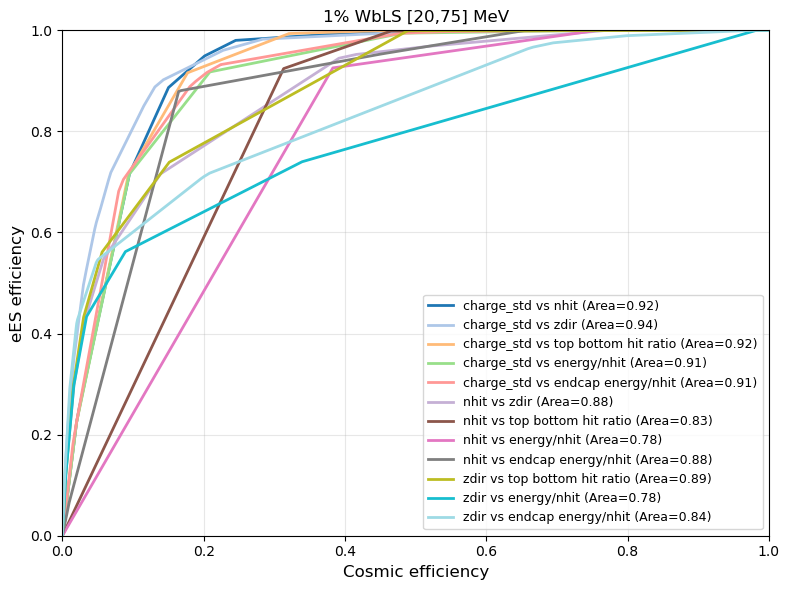

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab20(np.linspace(0, 1, len(roc_results)))
for i, (label, (cos_eff, ox_eff)) in enumerate(roc_results.items()):
    order = np.argsort(cos_eff)
    auc = np.trapz(ox_eff[order], cos_eff[order])
    ax.plot(cos_eff, ox_eff, label=f"{label} (Area={auc:.2f})", color=colors[i], lw=2)

ax.set_xlabel('Cosmic efficiency', fontsize=12)
ax.set_ylabel('eES efficiency', fontsize=12)
ax.set_title('Water [20,75] MeV')
ax.set_title('1% WbLS [20,75] MeV')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Optional: zoom to low cosmic efficiency

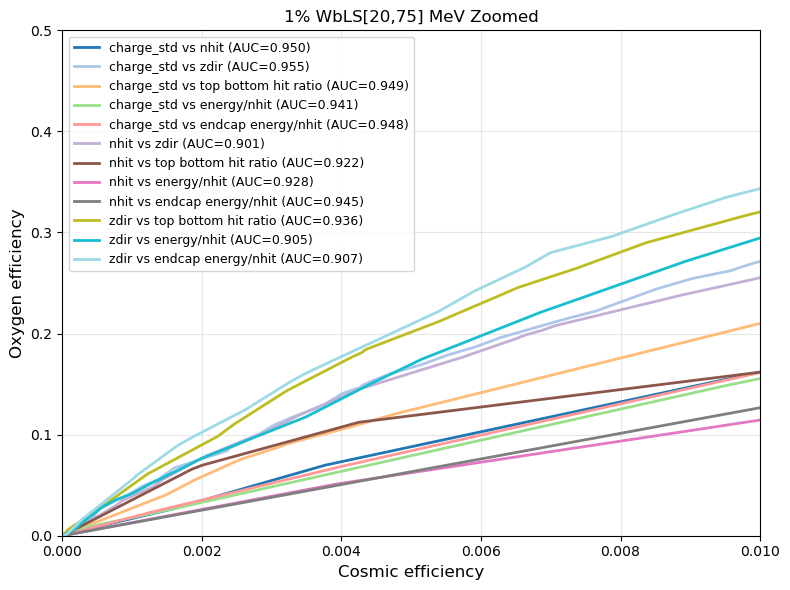

In [138]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab20(np.linspace(0, 1, len(roc_results)))
for i, (label, (cos_eff, ox_eff)) in enumerate(roc_results.items()):
    order = np.argsort(cos_eff)
    auc = np.trapz(ox_eff[order], cos_eff[order])
    ax.plot(cos_eff, ox_eff, label=f"{label} (AUC={auc:.3f})", color=colors[i], lw=2)

ax.set_xlabel('Cosmic efficiency', fontsize=12)
ax.set_ylabel('Oxygen efficiency', fontsize=12)
ax.set_title('Water [20,75] MeV Zoomed')# to 99% Cosmic Veto efficiency')
ax.set_title('1% WbLS[20,75] MeV Zoomed')# to 99% Cosmic Veto efficiency')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(0, 0.01)
ax.set_ylim(0, 0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [140]:
from itertools import combinations

# Variables to include in 3D likelihood-ratio comparisons.
# Trim this list if you want fewer ROC curves on the plots.
VAR3_VARIABLES = [
    "charge_std",
    "nhit",
    "zdir",
    "top bottom hit ratio",
    "energy/nhit",
    "endcap energy/nhit",
]

## Each entry: (var1_name, var2_name, var3_name, var1_bins, var2_bins, var3_bins)
#VAR3_COMBINATIONS = [
#    (v1, v2, v3, VAR_BINS[v1], VAR_BINS[v2], VAR_BINS[v3])
#    for v1, v2, v3 in combinations(VAR3_VARIABLES, 3)
#]
VAR3_COMBINATIONS = [
    ("charge_std", "nhit", "zdir", VAR_BINS["charge_std"], VAR_BINS["nhit"], VAR_BINS['zdir']) ,
    ("charge_std", "nhit", "top bottom hit ratio",  VAR_BINS["charge_std"], VAR_BINS["nhit"], VAR_BINS['top bottom hit ratio']),
    ("charge_std", "zdir", "top bottom hit ratio",  VAR_BINS["charge_std"], VAR_BINS["zdir"], VAR_BINS['top bottom hit ratio']),
    ("charge_std", "zdir", "endcap energy/nhit",  VAR_BINS["charge_std"], VAR_BINS["zdir"], VAR_BINS['endcap energy/nhit']),
    ("nhit", "zdir", "endcap energy/nhit",  VAR_BINS["nhit"], VAR_BINS["zdir"], VAR_BINS['endcap energy/nhit']),
    ("nhit", "zdir", "top bottom hit ratio",  VAR_BINS["nhit"], VAR_BINS["zdir"], VAR_BINS['top bottom hit ratio']),
]


def compute_roc_for_combination_3d(
    var1_name,
    var2_name,
    var3_name,
    var1_bins,
    var2_bins,
    var3_bins,
    paths,
    norm_factors,
    emin,
    emax,
):
    """Build the 3D LR on one half of the data and evaluate ROC on the other half."""
    train_hists = {}
    test_hists = {}
    for i, (name, path) in enumerate(paths.items()):
        data = np.load(path, allow_pickle=True)
        v1 = extract_var(data, var1_name, emin, emax)
        v2 = extract_var(data, var2_name, emin, emax)
        v3 = extract_var(data, var3_name, emin, emax)
        fin = np.isfinite(v1) & np.isfinite(v2) & np.isfinite(v3)
        v1, v2, v3 = v1[fin], v2[fin], v3[fin]
        if var1_bins is None or var2_bins is None or var3_bins is None:
            raise ValueError(
                f"Explicit bins required for {var1_name} vs {var2_name} vs {var3_name}"
            )

        (v1_train, v2_train, v3_train), (v1_test, v2_test, v3_test) = split_train_test_arrays(
            [v1, v2, v3],
            train_fraction=CV_TRAIN_FRACTION,
            seed=CV_SEED + i,
        )

        train_values = np.column_stack([v1_train, v2_train, v3_train])
        test_values = np.column_stack([v1_test, v2_test, v3_test])
        h_train, _ = np.histogramdd(train_values, bins=[var1_bins, var2_bins, var3_bins])
        h_test, _ = np.histogramdd(test_values, bins=[var1_bins, var2_bins, var3_bins])

        n_train = h_train.sum()
        n_test = h_test.sum()
        if n_train > 0:
            h_train = h_train * (norm_factors[name] / n_train)
        if n_test > 0:
            h_test = h_test * (norm_factors[name] / n_test)

        train_hists[name] = h_train
        test_hists[name] = h_test

    h_ox_train = train_hists["oxygen"]
    h_cos_train = train_hists["cosmics"] + 1e-10
    ratio = np.where(h_cos_train > 0, h_ox_train / h_cos_train, np.nan)
    ratio_val = np.where(np.isfinite(ratio) & (ratio > 0), ratio, 0.0)

    h_ox_test = test_hists["oxygen"]
    h_cos_test = test_hists["cosmics"]
    tot_ox = np.sum(h_ox_test)
    tot_cos = np.sum(h_cos_test)
    if tot_ox <= 0 or tot_cos <= 0:
        return None, None

    pos = ratio_val > 0
    lr_max = np.max(ratio_val[pos]) if np.any(pos) else 1.0
    lr_cuts = np.linspace(0, min(10, lr_max * 1.1), 3000)

    ox_eff = []
    cos_eff = []
    for thr in lr_cuts:
        sel = ratio_val >= thr
        ox_eff.append(h_ox_test[sel].sum() / tot_ox)
        cos_eff.append(h_cos_test[sel].sum() / tot_cos)
    return np.array(cos_eff), np.array(ox_eff)


print("Computing 3D ROC curves for each variable combination...")
roc_results_3d = {}
for var1, var2, var3, b1, b2, b3 in VAR3_COMBINATIONS:
    label = f"{var1} vs {var2} vs {var3}"
    cos_eff, ox_eff = compute_roc_for_combination_3d(
        var1, var2, var3, b1, b2, b3, paths, norm_factors, emin, emax
    )
    if cos_eff is not None:
        roc_results_3d[label] = (cos_eff, ox_eff)
        print(f"  {label}: OK")
    else:
        print(f"  {label}: SKIP (no data)")

Computing 3D ROC curves for each variable combination...


  charge_std vs nhit vs zdir: OK
  charge_std vs nhit vs top bottom hit ratio: OK
  charge_std vs zdir vs top bottom hit ratio: OK
  charge_std vs zdir vs endcap energy/nhit: OK
  nhit vs zdir vs endcap energy/nhit: OK
  nhit vs zdir vs top bottom hit ratio: OK


## Plot 3D ROC comparison

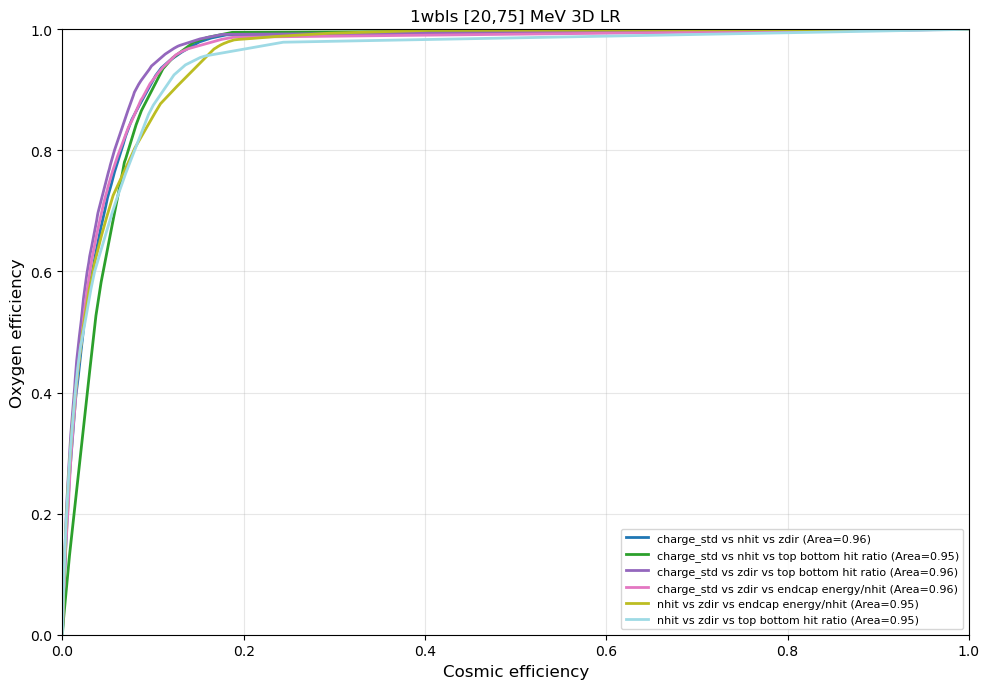

In [141]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.tab20(np.linspace(0, 1, len(roc_results_3d)))
for i, (label, (cos_eff, ox_eff)) in enumerate(roc_results_3d.items()):
    order = np.argsort(cos_eff)
    auc = np.trapz(ox_eff[order], cos_eff[order])
    ax.plot(cos_eff, ox_eff, label=f"{label} (Area={auc:.2f})", color=colors[i], lw=2)

ax.set_xlabel('Cosmic efficiency', fontsize=12)
ax.set_ylabel('Oxygen efficiency', fontsize=12)
ax.set_title(f'{detector.capitalize()} [{emin:.0f},{emax:.0f}] MeV 3D LR')
ax.legend(loc='lower right', fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

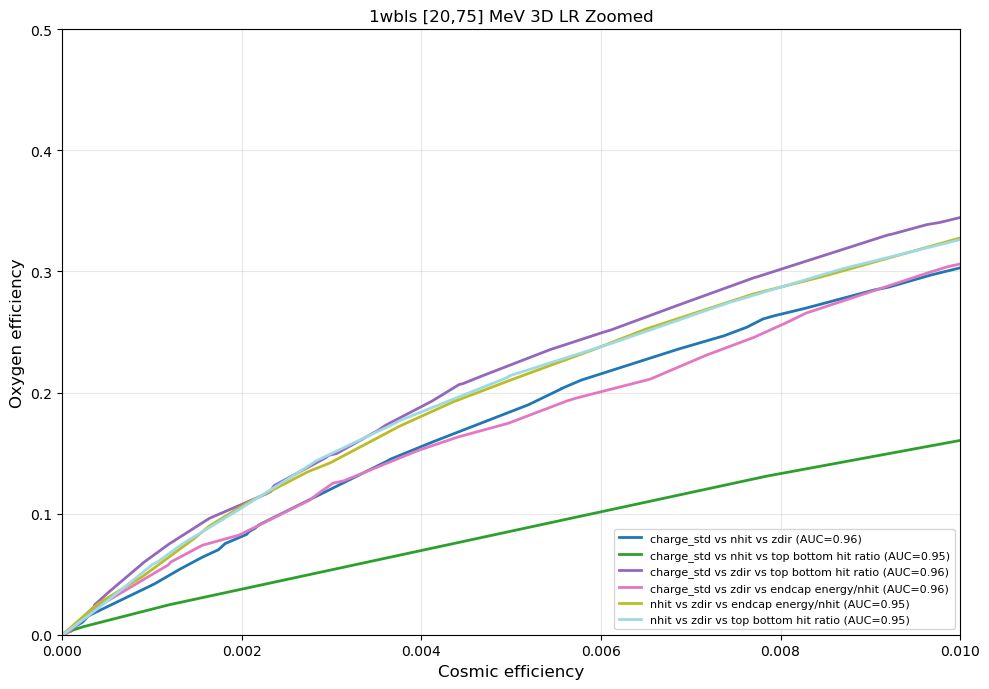

In [142]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.tab20(np.linspace(0, 1, len(roc_results_3d)))
for i, (label, (cos_eff, ox_eff)) in enumerate(roc_results_3d.items()):
    order = np.argsort(cos_eff)
    auc = np.trapz(ox_eff[order], cos_eff[order])
    ax.plot(cos_eff, ox_eff, label=f"{label} (AUC={auc:.2f})", color=colors[i], lw=2)

ax.set_xlabel('Cosmic efficiency', fontsize=12)
ax.set_ylabel('Oxygen efficiency', fontsize=12)
ax.set_title(f'{detector.capitalize()} [{emin:.0f},{emax:.0f}] MeV 3D LR Zoomed')
ax.legend(loc='lower right', fontsize=8)
ax.set_xlim(0, 0.01)
ax.set_ylim(0, 0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [144]:
# Each entry:
# (var1_name, var2_name, var3_name, var4_name, var1_bins, var2_bins, var3_bins, var4_bins)
VAR4_COMBINATIONS = [
    (
        "charge_std",
        "nhit",
        "zdir",
        "top bottom hit ratio",
        VAR_BINS["charge_std"],
        VAR_BINS["nhit"],
        VAR_BINS["zdir"],
        VAR_BINS["top bottom hit ratio"],
    ),
    (
        "charge_std",
        "nhit",
        "zdir",
        "endcap energy/nhit",
        VAR_BINS["charge_std"],
        VAR_BINS["nhit"],
        VAR_BINS["zdir"],
        VAR_BINS["endcap energy/nhit"],
    ),
    (
        "charge_std",
        "nhit",
        "zdir",
        "energy/nhit",
        VAR_BINS["charge_std"],
        VAR_BINS["nhit"],
        VAR_BINS["zdir"],
        VAR_BINS["energy/nhit"],
    ),
    (
        "charge_std",
        "zdir",
        "top bottom hit ratio",
        "endcap energy/nhit",
        VAR_BINS["charge_std"],
        VAR_BINS["zdir"],
        VAR_BINS["top bottom hit ratio"],
        VAR_BINS["endcap energy/nhit"],
    ),
]


def compute_roc_for_combination_4d(
    var1_name,
    var2_name,
    var3_name,
    var4_name,
    var1_bins,
    var2_bins,
    var3_bins,
    var4_bins,
    paths,
    norm_factors,
    emin,
    emax,
):
    """Build the 4D LR on one half of the data and evaluate ROC on the other half."""
    train_hists = {}
    test_hists = {}
    for i, (name, path) in enumerate(paths.items()):
        data = np.load(path, allow_pickle=True)
        v1 = extract_var(data, var1_name, emin, emax)
        v2 = extract_var(data, var2_name, emin, emax)
        v3 = extract_var(data, var3_name, emin, emax)
        v4 = extract_var(data, var4_name, emin, emax)
        fin = np.isfinite(v1) & np.isfinite(v2) & np.isfinite(v3) & np.isfinite(v4)
        v1, v2, v3, v4 = v1[fin], v2[fin], v3[fin], v4[fin]
        if var1_bins is None or var2_bins is None or var3_bins is None or var4_bins is None:
            raise ValueError(
                f"Explicit bins required for {var1_name} vs {var2_name} vs {var3_name} vs {var4_name}"
            )

        (v1_train, v2_train, v3_train, v4_train), (v1_test, v2_test, v3_test, v4_test) = split_train_test_arrays(
            [v1, v2, v3, v4],
            train_fraction=CV_TRAIN_FRACTION,
            seed=CV_SEED + i,
        )

        train_values = np.column_stack([v1_train, v2_train, v3_train, v4_train])
        test_values = np.column_stack([v1_test, v2_test, v3_test, v4_test])
        h_train, _ = np.histogramdd(train_values, bins=[var1_bins, var2_bins, var3_bins, var4_bins])
        h_test, _ = np.histogramdd(test_values, bins=[var1_bins, var2_bins, var3_bins, var4_bins])

        n_train = h_train.sum()
        n_test = h_test.sum()
        if n_train > 0:
            h_train = h_train * (norm_factors[name] / n_train)
        if n_test > 0:
            h_test = h_test * (norm_factors[name] / n_test)

        train_hists[name] = h_train
        test_hists[name] = h_test

    h_ox_train = train_hists["oxygen"]
    h_cos_train = train_hists["cosmics"] + 1e-10
    ratio = np.where(h_cos_train > 0, h_ox_train / h_cos_train, np.nan)
    ratio_val = np.where(np.isfinite(ratio) & (ratio > 0), ratio, 0.0)

    h_ox_test = test_hists["oxygen"]
    h_cos_test = test_hists["cosmics"]
    tot_ox = np.sum(h_ox_test)
    tot_cos = np.sum(h_cos_test)
    if tot_ox <= 0 or tot_cos <= 0:
        return None, None

    pos = ratio_val > 0
    lr_max = np.max(ratio_val[pos]) if np.any(pos) else 1.0
    lr_cuts = np.linspace(0, min(10, lr_max * 1.1), 3000)

    ox_eff = []
    cos_eff = []
    for thr in lr_cuts:
        sel = ratio_val >= thr
        ox_eff.append(h_ox_test[sel].sum() / tot_ox)
        cos_eff.append(h_cos_test[sel].sum() / tot_cos)
    return np.array(cos_eff), np.array(ox_eff)


print("Computing 4D ROC curves for each variable combination...")
roc_results_4d = {}
for var1, var2, var3, var4, b1, b2, b3, b4 in VAR4_COMBINATIONS:
    label = f"{var1} vs {var2} vs {var3} vs {var4}"
    cos_eff, ox_eff = compute_roc_for_combination_4d(
        var1, var2, var3, var4, b1, b2, b3, b4, paths, norm_factors, emin, emax
    )
    if cos_eff is not None:
        roc_results_4d[label] = (cos_eff, ox_eff)
        print(f"  {label}: OK")
    else:
        print(f"  {label}: SKIP (no data)")

Computing 4D ROC curves for each variable combination...
  charge_std vs nhit vs zdir vs top bottom hit ratio: OK
  charge_std vs nhit vs zdir vs endcap energy/nhit: OK
  charge_std vs nhit vs zdir vs energy/nhit: OK
  charge_std vs zdir vs top bottom hit ratio vs endcap energy/nhit: OK


## Plot 4D ROC comparison

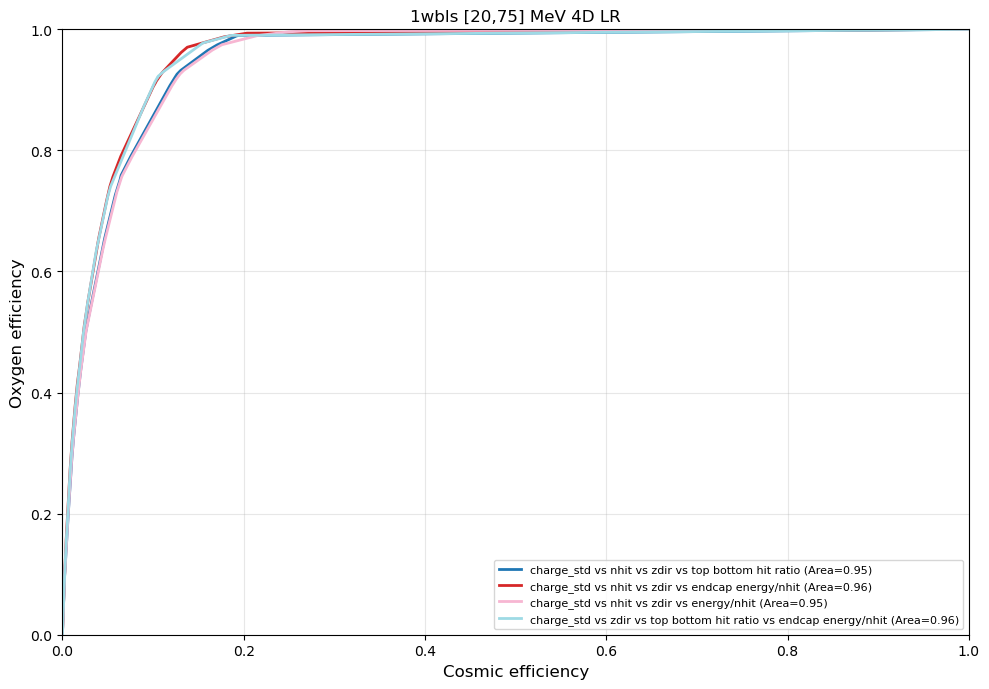

In [145]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.tab20(np.linspace(0, 1, len(roc_results_4d)))
for i, (label, (cos_eff, ox_eff)) in enumerate(roc_results_4d.items()):
    order = np.argsort(cos_eff)
    auc = np.trapz(ox_eff[order], cos_eff[order])
    ax.plot(cos_eff, ox_eff, label=f"{label} (Area={auc:.2f})", color=colors[i], lw=2)

ax.set_xlabel('Cosmic efficiency', fontsize=12)
ax.set_ylabel('Oxygen efficiency', fontsize=12)
ax.set_title(f'{detector.capitalize()} [{emin:.0f},{emax:.0f}] MeV 4D LR')
ax.legend(loc='lower right', fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Optional: zoomed 4D ROC comparison

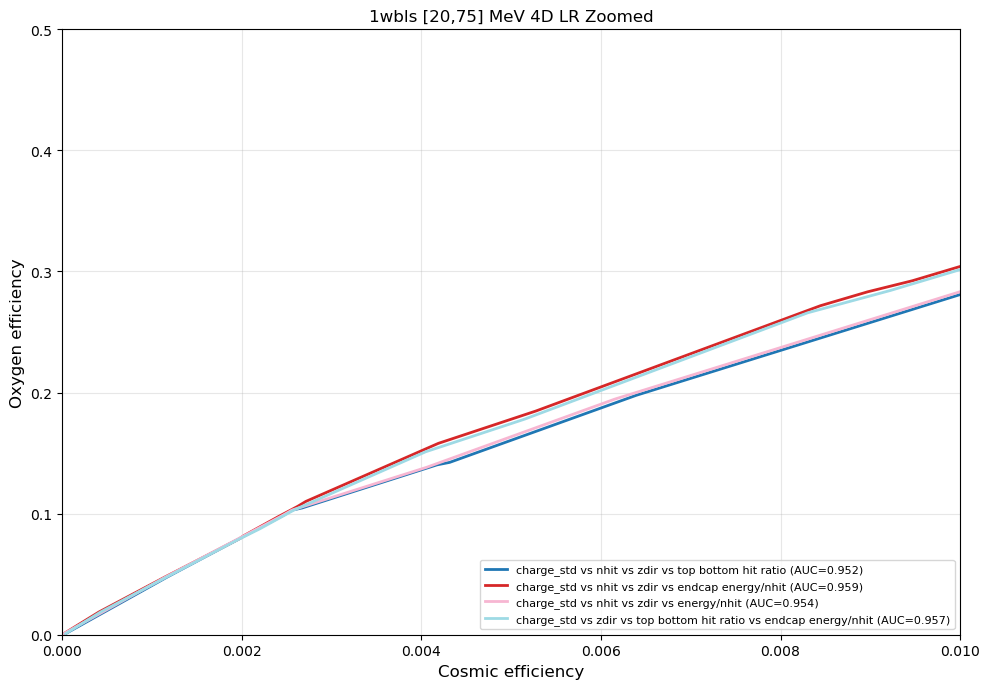

In [146]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.tab20(np.linspace(0, 1, len(roc_results_4d)))
for i, (label, (cos_eff, ox_eff)) in enumerate(roc_results_4d.items()):
    order = np.argsort(cos_eff)
    auc = np.trapz(ox_eff[order], cos_eff[order])
    ax.plot(cos_eff, ox_eff, label=f"{label} (AUC={auc:.3f})", color=colors[i], lw=2)

ax.set_xlabel('Cosmic efficiency', fontsize=12)
ax.set_ylabel('Oxygen efficiency', fontsize=12)
ax.set_title(f'{detector.capitalize()} [{emin:.0f},{emax:.0f}] MeV 4D LR Zoomed')
ax.legend(loc='lower right', fontsize=8)
ax.set_xlim(0, 0.01)
ax.set_ylim(0, 0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
FISHER_VARIABLES = [
    "charge_std",
    "nhit",
    "zdir",
    "top bottom hit ratio",
    "endcap energy/nhit",
    "energy/nhit",
]

# Small diagonal regularization for the pooled covariance matrix.
FISHER_REG = 1e-6


def load_feature_matrix(path, variable_names, emin, emax):
    data = np.load(path, allow_pickle=True)
    columns = [extract_var(data, name, emin, emax) for name in variable_names]
    X = np.column_stack(columns)
    finite = np.all(np.isfinite(X), axis=1)
    return X[finite]


def split_feature_matrix(X, train_fraction=0.5, seed=12345):
    rng = np.random.default_rng(seed)
    order = rng.permutation(len(X))
    n_train = int(train_fraction * len(X))
    n_train = max(1, min(len(X) - 1, n_train))
    train_idx = order[:n_train]
    test_idx = order[n_train:]
    return X[train_idx], X[test_idx]


def compute_fisher_scores(paths, variable_names, emin, emax, reg=1e-6):
    X_ox = load_feature_matrix(paths["eES"], variable_names, emin, emax)
    X_cos = load_feature_matrix(paths["cosmics"], variable_names, emin, emax)

    X_ox_train, X_ox_test = split_feature_matrix(
        X_ox,
        train_fraction=CV_TRAIN_FRACTION,
        seed=CV_SEED,
    )
    X_cos_train, X_cos_test = split_feature_matrix(
        X_cos,
        train_fraction=CV_TRAIN_FRACTION,
        seed=CV_SEED + 1,
    )

    mu_ox = X_ox_train.mean(axis=0)
    mu_cos = X_cos_train.mean(axis=0)

    cov_ox = np.cov(X_ox_train, rowvar=False)
    cov_cos = np.cov(X_cos_train, rowvar=False)
    pooled = cov_ox + cov_cos
    pooled = pooled + reg * np.eye(pooled.shape[0])

    w = np.linalg.pinv(pooled) @ (mu_ox - mu_cos)
    b = -0.5 * np.dot(w, mu_ox + mu_cos)

    score_ox = X_ox_test @ w + b
    score_cos = X_cos_test @ w + b

    return {
        "X_ox_train": X_ox_train,
        "X_cos_train": X_cos_train,
        "X_ox_test": X_ox_test,
        "X_cos_test": X_cos_test,
        "mu_ox": mu_ox,
        "mu_cos": mu_cos,
        "w": w,
        "b": b,
        "score_ox": score_ox,
        "score_cos": score_cos,
    }


def compute_fisher_roc(score_ox, score_cos, n_cuts=3000):
    all_scores = np.concatenate([score_ox, score_cos])
    cuts = np.linspace(np.nanmin(all_scores), np.nanmax(all_scores), n_cuts)

    ox_eff = []
    cos_eff = []
    for thr in cuts:
        ox_eff.append(np.mean(score_ox >= thr))
        cos_eff.append(np.mean(score_cos >= thr))

    return cuts, np.array(cos_eff), np.array(ox_eff)


fisher_results = compute_fisher_scores(paths, FISHER_VARIABLES, emin, emax, reg=FISHER_REG)
fisher_cuts, fisher_cos_eff, fisher_ox_eff = compute_fisher_roc(
    fisher_results["score_ox"],
    fisher_results["score_cos"],
)

print("Fisher variables:", FISHER_VARIABLES)
print("Oxygen train/test events used:", len(fisher_results["X_ox_train"]), len(fisher_results["score_ox"]))
print("Cosmic train/test events used:", len(fisher_results["X_cos_train"]), len(fisher_results["score_cos"]))
print("Fisher coefficients:")
for name, coeff in zip(FISHER_VARIABLES, fisher_results["w"]):
    print(f"  {name:20s} {coeff: .6e}")

Fisher variables: ['charge_std', 'nhit', 'zdir', 'top bottom hit ratio', 'endcap energy/nhit', 'energy/nhit']
Oxygen train/test events used: 19778 19779
Cosmic train/test events used: 206247 206247
Fisher coefficients:
  charge_std           -1.151228e-01
  nhit                 -1.413983e-02
  zdir                  3.260218e+00
  top bottom hit ratio -9.373231e-08
  endcap energy/nhit    9.161871e-01
  energy/nhit           2.952578e+00


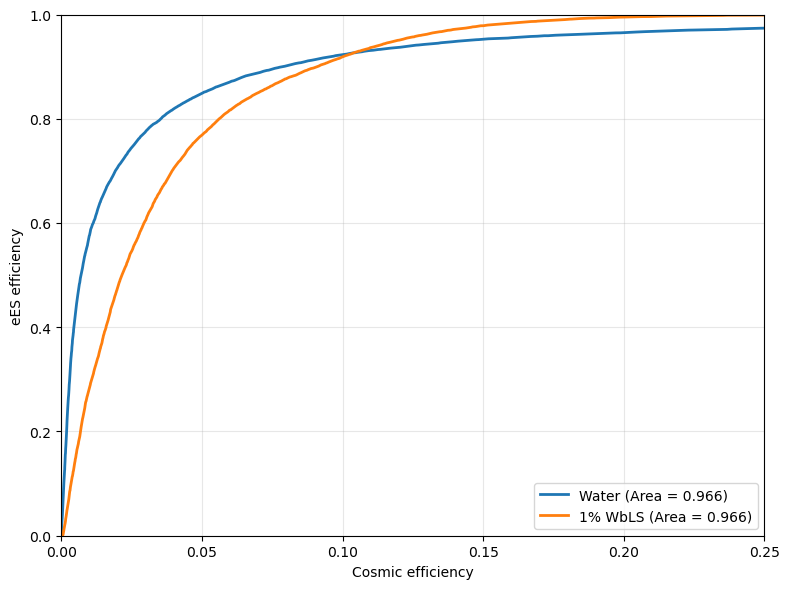

In [39]:
fig, ax = plt.subplots(figsize=(8, 6))
order = np.argsort(fisher_cos_eff)
fisher_auc = np.trapz(fisher_ox_eff[order], fisher_cos_eff[order])
ax.plot(fisher_cos_eff, fisher_ox_eff, lw=2, label=f"Water (Area = {fisher_auc:.3f})")
ax.plot(wbls_fisher_cos_eff, wbls_fisher_ox_eff, lw=2, label=f"1% WbLS (Area = {fisher_auc:.3f})")
ax.set_xlabel("Cosmic efficiency")
ax.set_ylabel("eES efficiency")
#ax.set_title(f"{detector.capitalize()} [{emin:.0f},{emax:.0f}] MeV Linear Fisher Discriminant ROC")
ax.set_xlim(0, 0.25)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


In [42]:
# Choose a target cosmic efficiency and get the nearest Fisher cut.
TARGET_COSMIC_EFF = 0.001

idx = np.argmin(np.abs(fisher_cos_eff - TARGET_COSMIC_EFF))
fisher_cut = fisher_cuts[idx]
print(f"Target cosmic efficiency: {TARGET_COSMIC_EFF:.4f}")
print(f"Chosen Fisher cut: {fisher_cut:.6f}")
print(f"Actual cosmic efficiency: {fisher_cos_eff[idx]:.6f}")
print(f"Actual oxygen efficiency: {fisher_ox_eff[idx]:.6f}")

Target cosmic efficiency: 0.0010
Chosen Fisher cut: 3.551803
Actual cosmic efficiency: 0.001004
Actual oxygen efficiency: 0.112999


In [27]:
wbls_fisher_cos_eff = fisher_cos_eff
wbls_fisher_ox_eff = fisher_ox_eff
